# 11. 최소제곱법 응용

## 실제 회귀에서 만나는 문제들

- **배울 것**: 범주 인코딩, 다중공선성, 릿지 정규화, 다항 회귀, 평가 지표.
- 서울 자전거 데이터에서는 강우량과 계절 또는 기온으로 대여량을 근사합니다. 계절은 봄·여름=1, 가을·겨울=0으로 묶습니다.
- 이 이진화는 원본의 교육용 단순화입니다. 두 집단을 그림에서 Summer/Winter로 표시하지만 정확히는 두 계절씩 묶은 값입니다.

## 같은 정보를 여러 열에 넣으면?

$$
x_3=4x_1+0.4x_2\Rightarrow\operatorname{rank}(X)<\text{열 수}
$$

- 새 열이 기존 열들의 선형결합이면 설명 가능한 공간은 커지지 않습니다. 계수 표현은 여러 개가 됩니다.
- 정규방정식의 역행렬은 존재하지 않거나 반올림 오차 때문에 불안정하게 계산됩니다. `lstsq`는 최소노름 최소제곱해를 구할 수 있습니다.
- 계수가 서로 달라도 예측값이 같을 수 있으므로 계수 비교와 예측 비교를 분리합니다.

## 릿지는 계수의 크기도 함께 줄인다

$$
\hat\beta_\lambda=\arg\min_\beta\left(\|y-X\beta\|^2+\lambda\|\beta\|^2\right)
=(X^TX+\lambda I)^{-1}X^Ty
$$

- $\lambda>0$이면 작은 고윳값을 들어 올려 수치적 불안정을 완화합니다. 너무 크면 필요한 신호까지 줄여 편향이 커집니다.
- 원본에서는 $\lambda=\gamma\|X\|_F^2$로 스케일을 정하고 절편까지 벌점에 포함합니다. 절편을 제외하는 관례와 구분해야 합니다.
- 다항 회귀도 계수에는 선형입니다. $1,x,x^2,x^3$을 열로 쌓으면 같은 최소제곱 문제입니다. 큰 연도를 바로 거듭제곱하면 조건수가 커지므로 중심화·스케일링이 유리합니다.
- 원본 인구 배가시간 목록에는 과거 전망 연도가 포함되어 있습니다. 현재 인구 예측으로 해석하지 않고 제공된 고정 예제로 다룹니다.

## 상관계수 제곱과 결정계수 구분

$$
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}
$$

- 절편이 있는 비정규화 OLS를 **적합한 학습 표본**에서는 이 값과 $\operatorname{corr}(y,\hat y)^2$가 일치합니다.
- 임의의 계수, 정규화 예측, 검증 표본에서는 일반적으로 같지 않습니다. 아래 원본의 `modelfit`, `r2` 중 상관제곱 계산은 그 이름 그대로 읽어야 합니다.
- 상관은 평균 이동과 양의 배율에 불변입니다. 따라서 상관제곱만 최대화해서 직선의 절편·기울기를 고를 수 없습니다. 실제 오차인 SSE를 비교해야 합니다.
- **주의**: 여기의 학습 적합도는 미래 예측 성능이 아닙니다. 모델 선택에는 별도 검증 표본이 필요합니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch11'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260936)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260936)

재현용 난수 시드: 20260936


### 코드 11-01

- 원본: `original_py/LA4DS_ch11.py` 1–9행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 서울 자전거 대여량 회귀

### 코드 11-02

- 원본: `original_py/LA4DS_ch11.py` 11–20행.
- **보완**: 서울 자전거 원자료의 로컬 사본을 사용합니다.

In [3]:
# Data citation: Sathishkumar V E, Jangwoo Park, and Yongyun Cho. 'Using data mining techniques for bike sharing demand 
#                prediction in metropolitan city.' Computer Communications, Vol.153, pp.353-366, March, 2020
# data source website: https://archive.ics.uci.edu/ml/datasets/Seoul+Bike+Sharing+Demand

# import the data
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00560/SeoulBikeData.csv"
data = pd.read_csv(DATA / 'SeoulBikeData.csv',sep=',',encoding='unicode_escape')

# let's have a look
data

Out[3]: 
            Date  Rented Bike Count  Hour  ...  Seasons     Holiday  Functioning Day
0     01/12/2017                254     0  ...   Winter  No Holiday              Yes
1     01/12/2017                204     1  ...   Winter  No Holiday              Yes
2     01/12/2017                173     2  ...   Winter  No Holiday              Yes
3     01/12/2017                107     3  ...   Winter  No Holiday              Yes
4     01/12/2017                 78     4  ...   Winter  No Holiday              Yes
...          ...                ...   ...  ...      ...         ...              ...
8755  30/11/2018               1003    19  ...   Autumn  No Holiday              Yes
8756  30/11/2018                764    20  ...   Autumn  No Holiday              Yes
8757  30/11/2018                694    21  ...   Autumn  No Holiday              Yes
8758  30/11/2018                712    22  ...   Autumn  No Holiday              Yes
8759  30/11/2018                584    23  ...   Autumn 

### 코드 11-03

- 원본: `original_py/LA4DS_ch11.py` 22–27행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

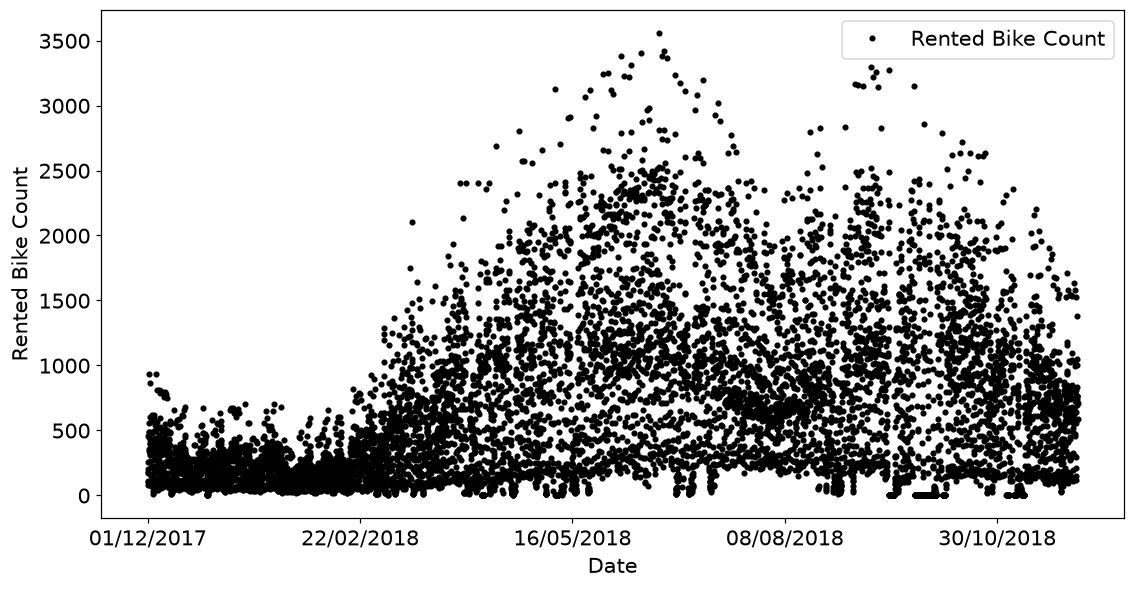

In [4]:
# show some data in scatter plots

data.plot(x='Date',y='Rented Bike Count',color='k',marker='.',linestyle='none',
          figsize=(12,6),ylabel='Rented Bike Count')
plt.savefig(ASSET / 'Figure_11_1a.png',dpi=140)
plt.show()

### 코드 11-04

- 원본: `original_py/LA4DS_ch11.py` 29–32행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

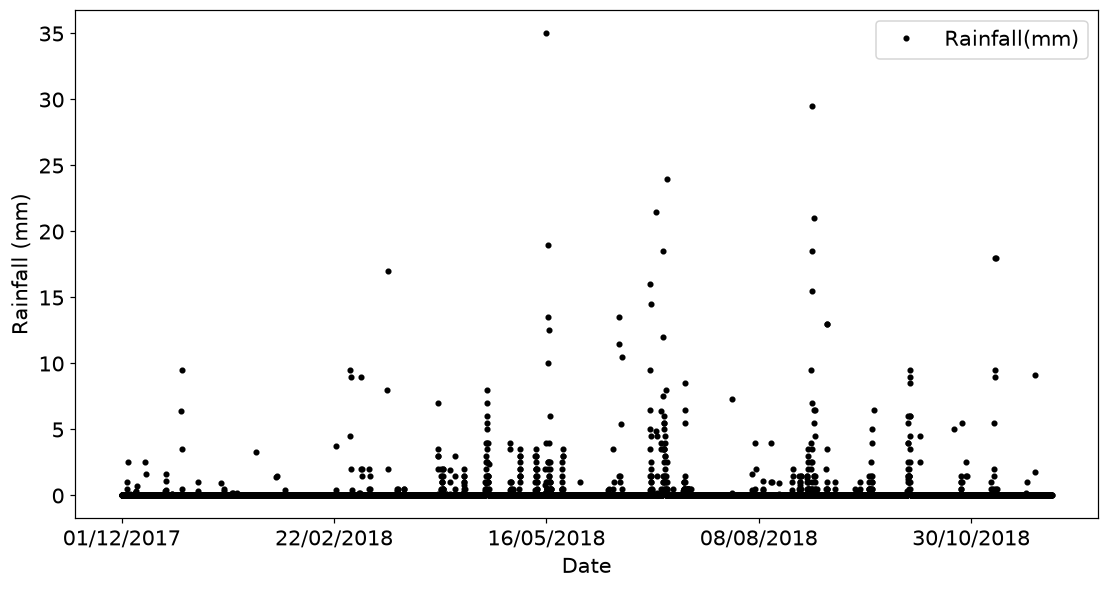

In [5]:
data.plot(x='Date',y='Rainfall(mm)',color='k',marker='.',linestyle='none',
          figsize=(12,6),ylabel='Rainfall (mm)');
plt.savefig(ASSET / 'Figure_11_1b.png',dpi=140)
plt.show()

### 코드 11-05

- 원본: `original_py/LA4DS_ch11.py` 34–35행.
- **보완**: 문자열 열이 있는 DataFrame의 최신 pandas 호환성을 보완했습니다.

In [6]:
# Examine the correlation matrix
data.corr(numeric_only=True)

Out[6]: 
                           Rented Bike Count  ...  Snowfall (cm)
Rented Bike Count                   1.000000  ...      -0.141804
Hour                                0.410257  ...      -0.021516
Temperature(°C)                     0.538558  ...      -0.218405
Humidity(%)                        -0.199780  ...       0.108183
Wind speed (m/s)                    0.121108  ...      -0.003554
Visibility (10m)                    0.199280  ...      -0.121695
Dew point temperature(°C)           0.379788  ...      -0.150887
Solar Radiation (MJ/m2)             0.261837  ...      -0.072301
Rainfall(mm)                       -0.123074  ...       0.008500
Snowfall (cm)                      -0.141804  ...       1.000000

[10 rows x 10 columns]


### 코드 11-06

- 원본: `original_py/LA4DS_ch11.py` 37–57행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

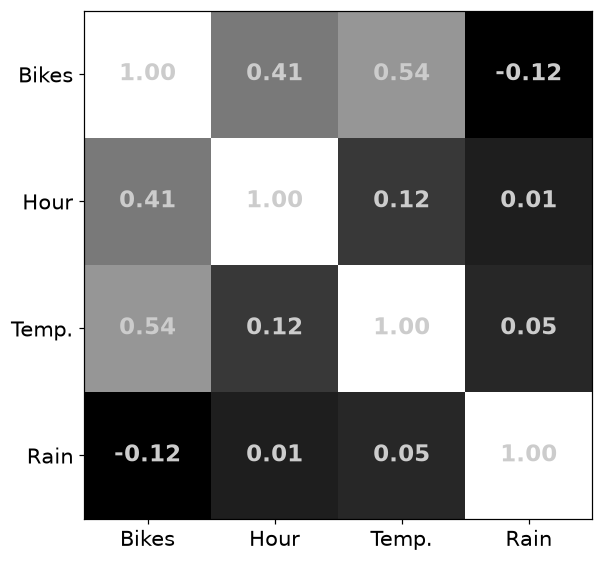

In [7]:
### show the correlation matrix in an image

# only using a few columns
columns2use = ['Rented Bike Count','Hour','Temperature(°C)','Rainfall(mm)']
colsshort = ['Bikes','Hour','Temp.','Rain'] # for axis labeleing

# re-compute the correlation matrix
R = data[columns2use].corr()

# draw the image
plt.figure(figsize=(6,6))
plt.imshow(R.values,cmap='gray')
plt.xticks(range(4),labels=colsshort)
plt.yticks(range(4),labels=colsshort)

# text labels
for (j,i),num in np.ndenumerate(R.values):
  plt.text(i,j,f'{num:.2f}',color=[.8,.8,.8],ha='center',va='center',fontweight='bold',fontsize=15)

plt.savefig(ASSET / 'Figure_11_02.png',dpi=140)
plt.show()

### 코드 11-07

- 원본: `original_py/LA4DS_ch11.py` 59–61행.
- **보완**: 계절 열만 명시적으로 숫자 인코딩합니다.

In [8]:
# binarize the seasons
data['Seasons'] = data['Seasons'].map({'Spring':1, 'Summer':1, 'Autumn':0, 'Winter':0}).astype(float)
data

Out[8]: 
            Date  Rented Bike Count  Hour  ...  Seasons     Holiday  Functioning Day
0     01/12/2017                254     0  ...      0.0  No Holiday              Yes
1     01/12/2017                204     1  ...      0.0  No Holiday              Yes
2     01/12/2017                173     2  ...      0.0  No Holiday              Yes
3     01/12/2017                107     3  ...      0.0  No Holiday              Yes
4     01/12/2017                 78     4  ...      0.0  No Holiday              Yes
...          ...                ...   ...  ...      ...         ...              ...
8755  30/11/2018               1003    19  ...      0.0  No Holiday              Yes
8756  30/11/2018                764    20  ...      0.0  No Holiday              Yes
8757  30/11/2018                694    21  ...      0.0  No Holiday              Yes
8758  30/11/2018                712    22  ...      0.0  No Holiday              Yes
8759  30/11/2018                584    23  ...      0.0 

### 코드 11-08

- 원본: `original_py/LA4DS_ch11.py` 63–81행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

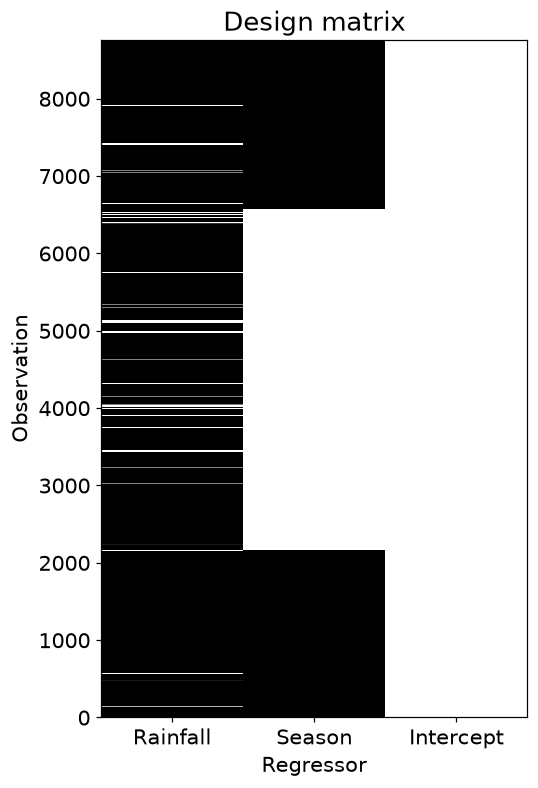

In [9]:
# Create a design matrix
desmat = data[['Rainfall(mm)','Seasons']].to_numpy()

# add an intercept
desmat = np.append(desmat,np.ones((desmat.shape[0],1)),axis=1)

# extract DV
y = data[['Rented Bike Count']].to_numpy()


# visualize the design matrix
plt.figure(figsize=(5,8))
plt.imshow(desmat,aspect='auto',vmin=0,vmax=1,origin='lower',interpolation='nearest',cmap='gray')
plt.ylabel('Observation')
plt.xlabel('Regressor')
plt.title('Design matrix')
plt.xticks(range(3),labels=['Rainfall','Season','Intercept'])
plt.savefig(ASSET / 'Figure_11_3a.png',dpi=140)
plt.show()

### 코드 11-09

- 원본: `original_py/LA4DS_ch11.py` 83–94행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

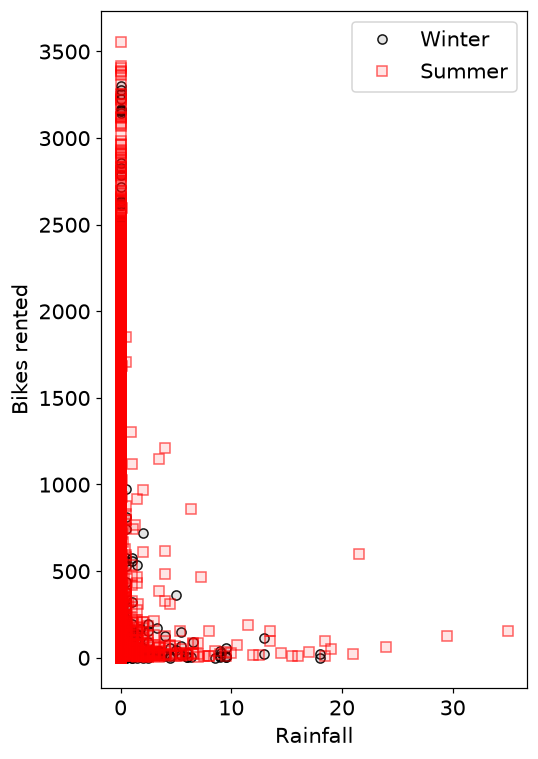

In [10]:
# plot the data
plt.figure(figsize=(5,8))

# separately for autumn/winter and spring/summer
plt.plot(desmat[desmat[:,1]==0,0],y[desmat[:,1]==0],'o',markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9),label='Winter')
plt.plot(desmat[desmat[:,1]==1,0],y[desmat[:,1]==1],'s',markerfacecolor=(1,0,0,.1),markeredgecolor=(1,0,0,.6),label='Summer')

plt.xlabel('Rainfall')
plt.ylabel('Bikes rented')
plt.legend()
plt.savefig(ASSET / 'Figure_11_3b.png',dpi=140)
plt.show()

### 코드 11-10

- 원본: `original_py/LA4DS_ch11.py` 96–98행.

In [11]:
# run the regression
beta = np.linalg.lstsq(desmat,y,rcond=None)
beta[0]

Out[11]: 
array([[-80.523675],
       [369.126681],
       [530.494596]])


### 코드 11-11

- 원본: `original_py/LA4DS_ch11.py` 100–118행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

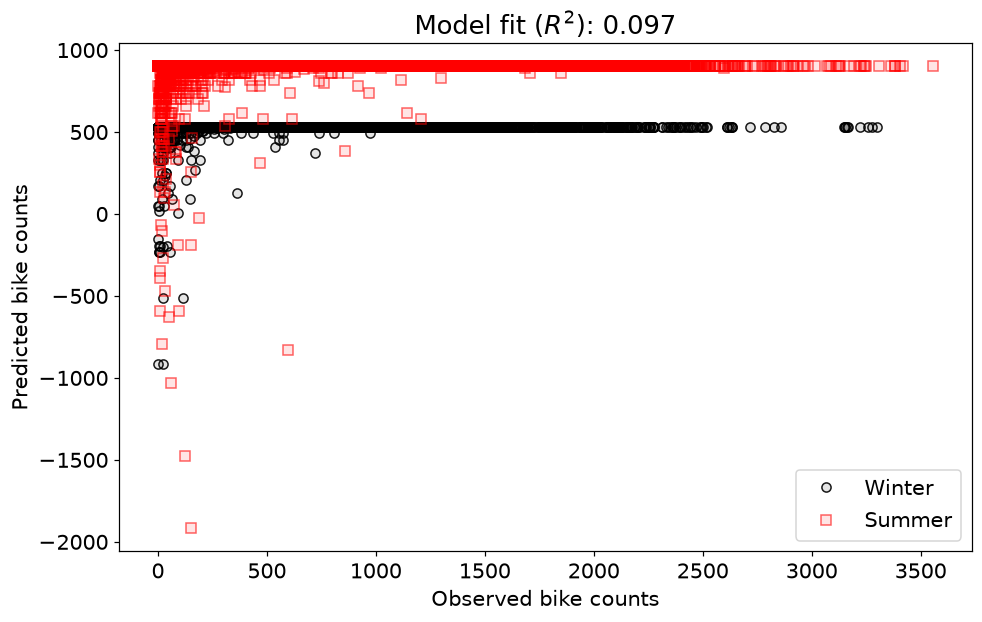

In [12]:
## plot some results.

# predicted data
yHat = desmat@beta[0]

# model fit to data (R^2)
modelfit = np.corrcoef(y.T,yHat.T)[0,1]**2


# and plot
plt.figure(figsize=(10,6))
plt.plot(y[desmat[:,1]==0],yHat[desmat[:,1]==0],'o',markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9),label='Winter')
plt.plot(y[desmat[:,1]==1],yHat[desmat[:,1]==1],'s',markerfacecolor=(1,0,0,.1),markeredgecolor=(1,0,0,.6),label='Summer')
plt.legend()
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Model fit ($R^2$): {modelfit:.3f}')
plt.savefig(ASSET / 'Figure_11_04.png',dpi=140)
plt.show()

### statsmodels 결과 읽기

### 코드 11-12

- 원본: `original_py/LA4DS_ch11.py` 120–129행.

In [13]:
import statsmodels.api as sm

# extract data (staying with pandas dataframes)
desmat_df  = data[['Rainfall(mm)','Seasons']]
obsdata_df = data['Rented Bike Count']

# create and fit the model
desmat_df = sm.add_constant(desmat_df) # must explicitly add an intercept (constant)
model = sm.OLS(obsdata_df,desmat_df).fit()
print( model.summary() )

                            OLS Regression Results                            
Dep. Variable:      Rented Bike Count   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     468.8
Date:                Fri, 25 Sep 2026   Prob (F-statistic):          3.80e-194
Time:                        12:55:31   Log-Likelihood:                -68654.
No. Observations:                8760   AIC:                         1.373e+05
Df Residuals:                    8757   BIC:                         1.373e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          530.4946      9.313     56.963   

### 다항 회귀

### 코드 11-13

- 원본: `original_py/LA4DS_ch11.py` 133–158행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

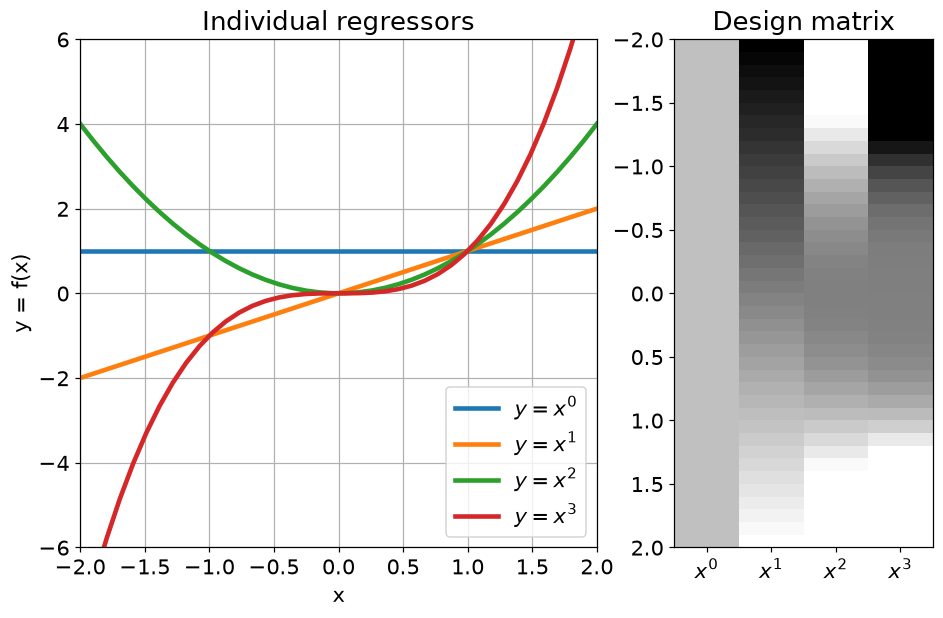

In [14]:
x = np.linspace(-2,2,40)
maxorder = 3
desmat = np.zeros((len(x),maxorder+1))
xlab = []


_,axs = plt.subplots(1,2,gridspec_kw={'width_ratios':[2,1]}, figsize=(10,6))

for i in range(maxorder+1):
  axs[0].plot(x,x**i,linewidth=3,label='$y=x^%g$'%i)
  desmat[:,i] = x**i
  xlab.append( '$x^%g$'%i )

axs[0].set(xlim=[-2,2],xlabel='x')
axs[0].set(ylim=[-6,6],ylabel='y = f(x)')
axs[0].grid()
axs[0].legend()
axs[0].set_title('Individual regressors')

# draw the design matrix
axs[1].imshow(desmat,cmap='gray',aspect='auto',vmin=-2,vmax=2,extent=[-.5,maxorder+.5,x[-1],x[0]])
axs[1].set(xticks=range(maxorder+1),xticklabels=xlab)
axs[1].set_title('Design matrix')

plt.savefig(ASSET / 'Figure_11_05.png',dpi=140)
plt.show()

### 코드 11-14

- 원본: `original_py/LA4DS_ch11.py` 162–181행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

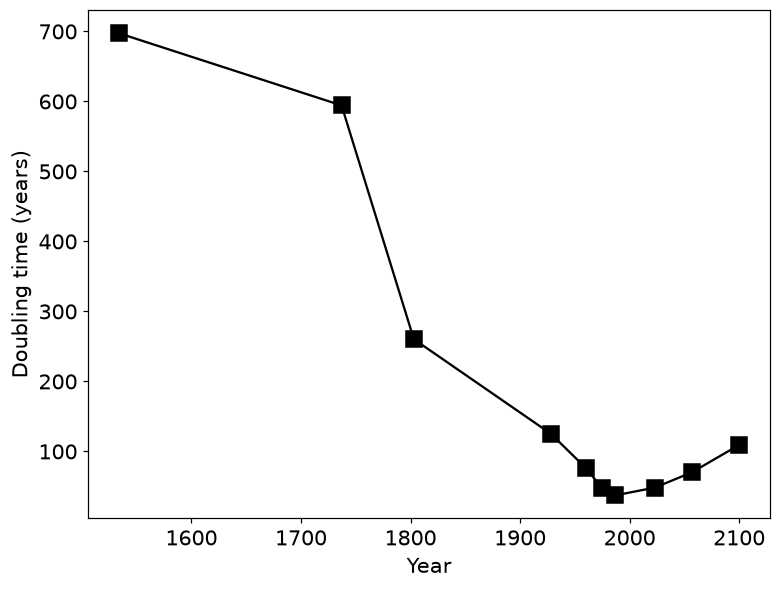

In [15]:
# the data
year       = [1534, 1737, 1803, 1928, 1960, 1975, 1987, 2023, 2057, 2100 ]
doubleTime = [ 697,  594,  260,  125,   76,   47,   37,   48,   70,  109 ]

N = len(year)


# plot it
plt.figure(figsize=(8,6))
plt.plot(year,doubleTime,'ks-',markersize=10)

plt.xlabel('Year')
plt.ylabel('Doubling time (years)')
plt.savefig(ASSET / 'Figure_11_06.png',dpi=140)
plt.show()

## DATA CITATION: 
#    Max Roser, Hannah Ritchie and Esteban Ortiz-Ospina (2013) - "World Population Growth".
#    Published online at OurWorldInData.org. Retrieved from: 'https://ourworldindata.org/world-population-growth'
#    https://ourworldindata.org/uploads/2019/12/World-population-doubling-time-1.png

### 코드 11-15

- 원본: `original_py/LA4DS_ch11.py` 183–192행.
- **보완**: 연도 거듭제곱에서 정수 오버플로를 방지합니다.

In [16]:
# design matrix for a 3rd-order polynomial
X = np.zeros((N,4))

# build the design matrix (note the range "4" because of indexing 0-3)
for i in range(4): 
  X[:,i] = np.array(year,dtype=float)**i


# converted to ints for your viewing pleasure
print(X.astype(int))

[[         1       1534    2353156 3609741304]
 [         1       1737    3017169 5240822553]
 [         1       1803    3250809 5861208627]
 [         1       1928    3717184 7166730752]
 [         1       1960    3841600 7529536000]
 [         1       1975    3900625 7703734375]
 [         1       1987    3948169 7845011803]
 [         1       2023    4092529 8279186167]
 [         1       2057    4231249 8703679193]
 [         1       2100    4410000 9261000000]]


### 코드 11-16

- 원본: `original_py/LA4DS_ch11.py` 194–210행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

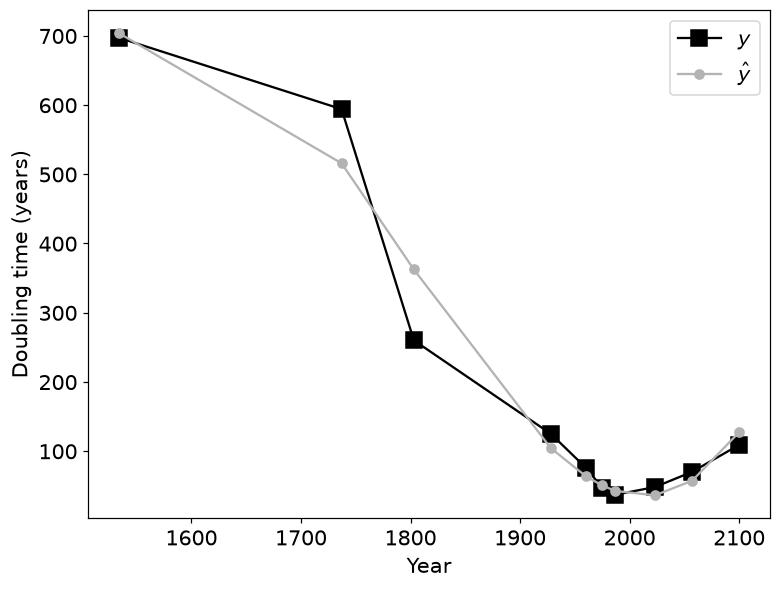

In [17]:
# compute the regression coefficients
beta = np.linalg.lstsq(X,doubleTime, rcond=None)

# and the predicted data
yHat = X@beta[0]


# plot it
plt.figure(figsize=(8,6))
plt.plot(year,doubleTime,'ks-',markersize=10,label=r'$y$')
plt.plot(year,yHat,'o-',color=[.7,.7,.7],label=r'$\hat{y}$')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Doubling time (years)')
plt.savefig(ASSET / 'Figure_11_07.png',dpi=140)
plt.show()

### 코드 11-17

- 원본: `original_py/LA4DS_ch11.py` 212–226행.

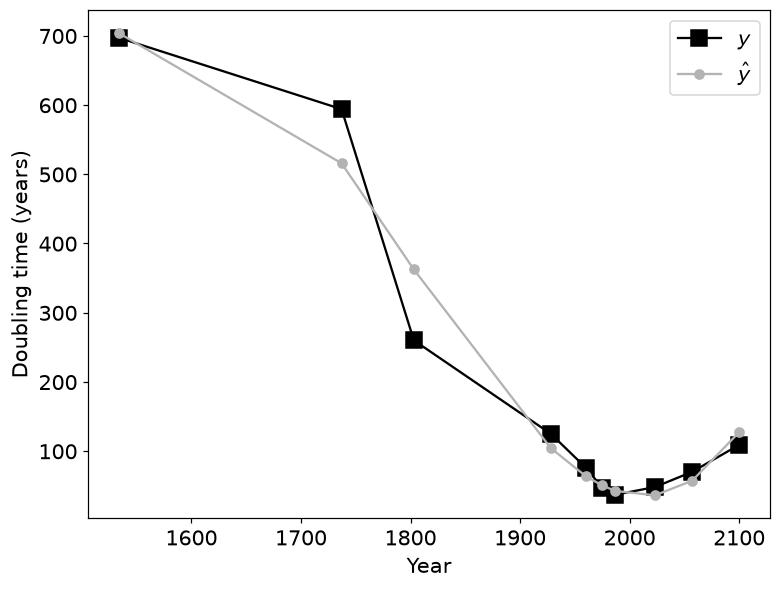

In [18]:
# Now using polyfit

beta = np.polyfit(year,doubleTime,3)
yHat = np.polyval(beta,year)


# plot it
plt.figure(figsize=(8,6))
plt.plot(year,doubleTime,'ks-',markersize=10,label=r'$y$')
plt.plot(year,yHat,'o-',color=[.7,.7,.7],label=r'$\hat{y}$')

plt.legend()
plt.xlabel('Year')
plt.ylabel('Doubling time (years)')
plt.show()

## 연습문제 1 · 비 오는 표본만 적합

- **목표**: 표본 선택이 적합 결과를 바꾸는지 관찰합니다.
- **풀이 순서**: 강우량>0 조건을 설계행렬과 y 양쪽에 같은 행 마스크로 적용하고 재적합합니다.
- **결과 해석**: 계수와 상관제곱 적합도가 달라집니다. 달라진 모집단과 표본 수를 고려해야 하며 전체 날짜 모델보다 무조건 우수하다는 의미는 아닙니다.

### 코드 11-18

- 원본: `original_py/LA4DS_ch11.py` 232–235행.

In [19]:
# re-create design matrix and data vector
desmat = data[['Rainfall(mm)','Seasons']].to_numpy()
desmat = np.append(desmat,np.ones((desmat.shape[0],1)),axis=1)
y = data[['Rented Bike Count']].to_numpy()

### 코드 11-19

- 원본: `original_py/LA4DS_ch11.py` 237–255행.

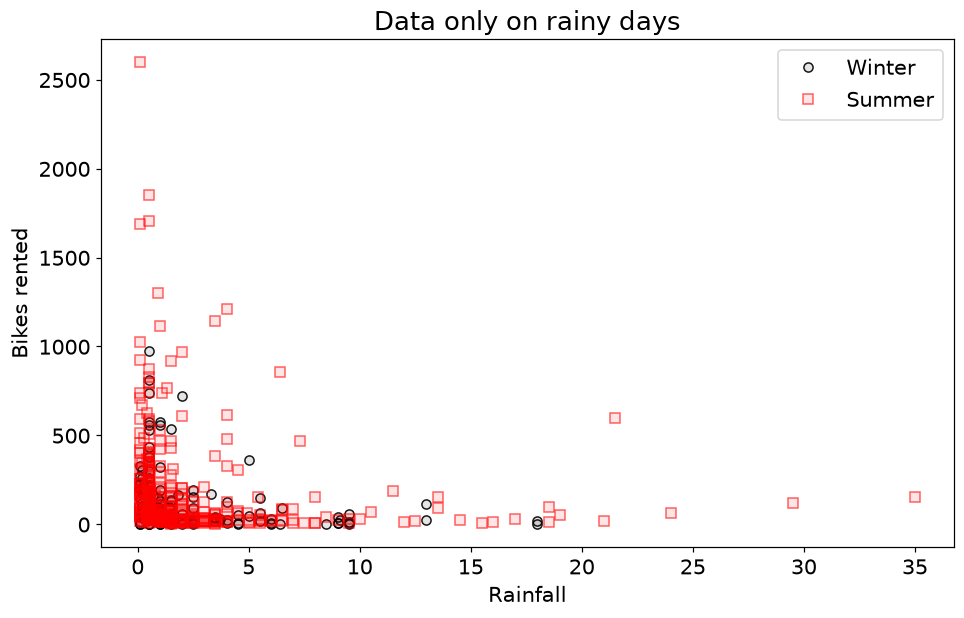

In [20]:
# repeat excluding zeros in rainfall

desmat_norain = desmat[desmat[:,0]>0,:]
y_norain = y[desmat[:,0]>0,:]

# plot the data
plt.figure(figsize=(10,6))

# separately for autumn/winter and spring/summer
plt.plot(desmat_norain[desmat_norain[:,1]==0,0],y_norain[desmat_norain[:,1]==0],'o',
         markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9),label='Winter')
plt.plot(desmat_norain[desmat_norain[:,1]==1,0],y_norain[desmat_norain[:,1]==1],'s',
         markerfacecolor=(1,0,0,.1),markeredgecolor=(1,0,0,.6),label='Summer')

plt.xlabel('Rainfall')
plt.ylabel('Bikes rented')
plt.title('Data only on rainy days')
plt.legend()
plt.show()

### 코드 11-20

- 원본: `original_py/LA4DS_ch11.py` 257–280행.

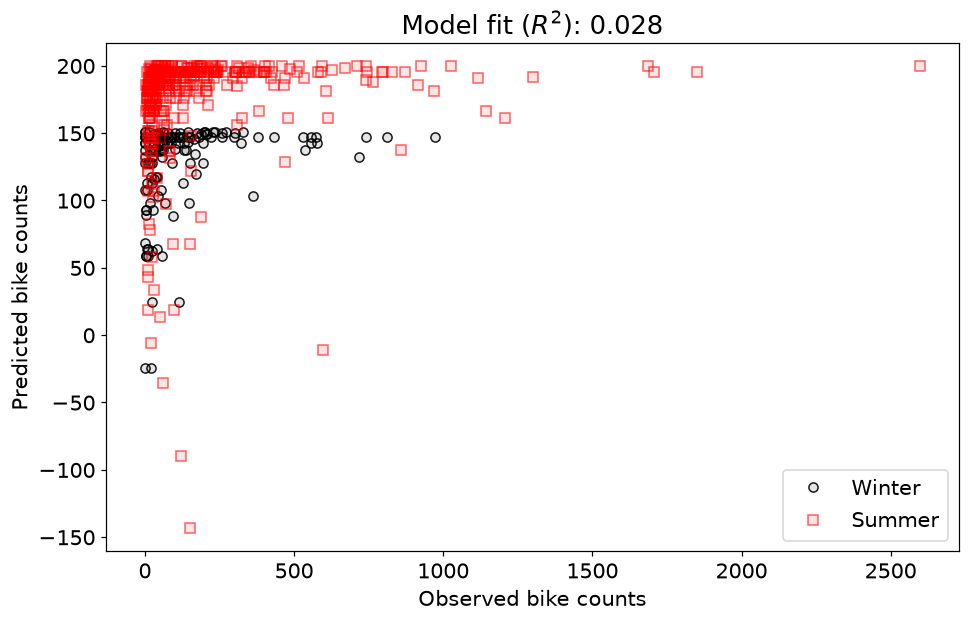

In [21]:
# run the regression (using np's least-squares)
beta_norain = np.linalg.lstsq(desmat_norain,y_norain,rcond=None)


# predicted data
yHat_norain = desmat_norain @ beta_norain[0]

# model fit to data (R^2)
modelfit = np.corrcoef(y_norain.T,yHat_norain.T)[0,1]**2



## plot some results.
plt.figure(figsize=(10,6))
plt.plot(y_norain[desmat_norain[:,1]==0],yHat_norain[desmat_norain[:,1]==0],'o',
         markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9),label='Winter')
plt.plot(y_norain[desmat_norain[:,1]==1],yHat_norain[desmat_norain[:,1]==1],'s',
         markerfacecolor=(1,0,0,.1),markeredgecolor=(1,0,0,.6),label='Summer')

plt.legend()
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Model fit ($R^2$): {modelfit:.3f}')
plt.show()

## 연습문제 2 · 계절 대신 기온

- **목표**: 설명변수를 바꾸어 대여량을 적합합니다.
- **풀이 순서**: 강우량·기온·절편으로 X를 새로 만들고 lstsq로 계수와 예측을 계산합니다.
- **결과 해석**: 예측-관측 산점도는 설명되지 않는 변동도 보여 줍니다. 학습 표본 적합도가 좋아져도 일반화는 별도 검증이 필요합니다.

### 코드 11-21

- 원본: `original_py/LA4DS_ch11.py` 284–302행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

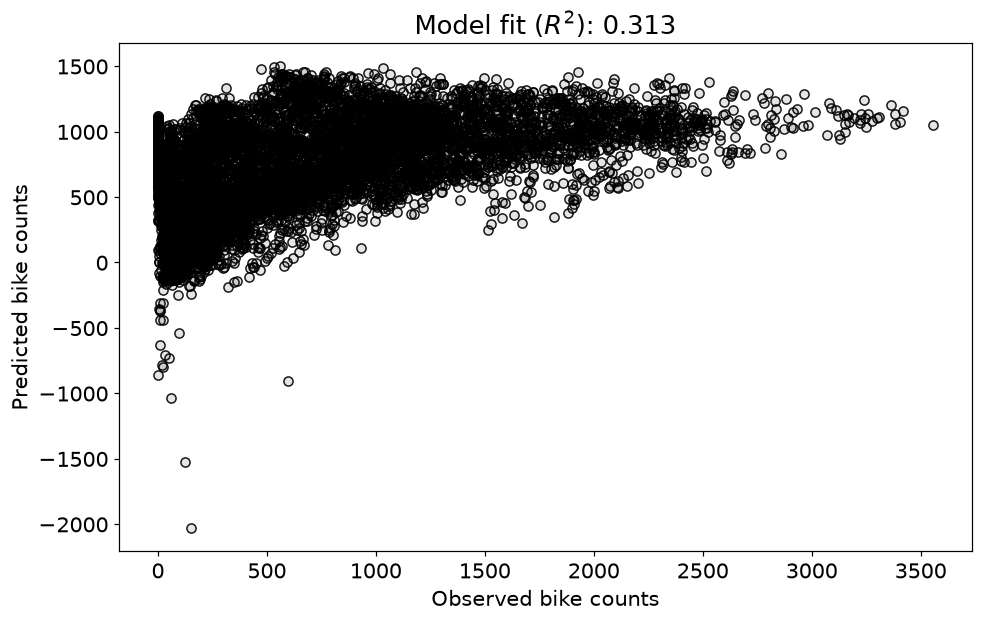

In [22]:
# Create a design matrix
desmat = data[['Rainfall(mm)','Temperature(°C)']].to_numpy()
desmat = np.append(desmat,np.ones((desmat.shape[0],1)),axis=1)


beta = np.linalg.lstsq(desmat,y,rcond=None)
yHat = desmat@beta[0]

# model fit to data (R^2)
modelfit = np.corrcoef(y.T,yHat.T)[0,1]**2

# and plot
plt.figure(figsize=(10,6))
plt.plot(y,yHat,'o',markerfacecolor=(0,0,0,.1),markeredgecolor=(0,0,0,.9))
plt.xlabel('Observed bike counts')
plt.ylabel('Predicted bike counts')
plt.title(f'Model fit ($R^2$): {modelfit:.3f}')
plt.savefig(ASSET / 'Figure_11_09.png',dpi=140)
plt.show()

## 연습문제 3 · 완전 다중공선성

- **목표**: 기존 열의 선형결합을 추가했을 때 계수의 비유일성을 관찰합니다.
- **풀이 순서**: 강우량과 기온으로 만든 새 열을 추가하고 rank를 확인합니다. 직접 역행렬, lstsq, statsmodels를 비교합니다.
- **결과 해석**: 열은 4개지만 rank는 3입니다. 직접 역행렬은 실패하거나 불안정합니다. 절편 열의 상관 NaN은 분산이 0이어서 정의되지 않는 값입니다.

### 코드 11-22

- 원본: `original_py/LA4DS_ch11.py` 306–325행.

In [23]:
# some random linear combination
lincombo = 4*desmat[:,0] + .4*desmat[:,1]

# Create a design matrix
desmatM = data[['Rainfall(mm)','Temperature(°C)']].to_numpy()
desmatM = np.append(desmatM,np.ones((desmatM.shape[0],1)),axis=1)

# augmented design matrix
desmatM = np.append(desmatM,lincombo.reshape(-1,1),axis=1)

# size and rank of the design matrix
print(f'Design matrix size: {desmatM.shape}')
print(f'Design matrix rank: {np.linalg.matrix_rank(desmatM)}')

# correlation matrix (note: nan's for intercept b/c no variance)
oSettings = np.seterr() # default error handling
np.seterr(all='ignore') # ignore warnings for correlation matrices
print(f'\nDesign matrix correlation matrix:')
print(np.round(np.corrcoef(desmatM.T),5))
np.seterr(**oSettings); # reset the error handling

Design matrix size: (8760, 4)
Design matrix rank: 3

Design matrix correlation matrix:
[[1.      0.05028     nan 0.7057 ]
 [0.05028 1.          nan 0.74309]
 [    nan     nan     nan     nan]
 [0.7057  0.74309     nan 1.     ]]


### 코드 11-23

- 원본: `original_py/LA4DS_ch11.py` 327–328행.

In [24]:
# A nicer way to print out the correlation matrix using pandas
pd.DataFrame(desmatM,columns=['Rain','Temp','Int','Combo']).corr()

Out[24]: 
           Rain      Temp  Int     Combo
Rain   1.000000  0.050282  NaN  0.705704
Temp   0.050282  1.000000  NaN  0.743094
Int         NaN       NaN  NaN       NaN
Combo  0.705704  0.743094  NaN  1.000000


### 코드 11-24

- 원본: `original_py/LA4DS_ch11.py` 330–342행.
- **보완**: 공선성 직접 역행렬이 환경에 따라 예외를 내면 실패를 명시하고, 다음 lstsq·statsmodels 비교를 계속합니다.

In [25]:
try:
    ### using left-inverse

    # fit the model using the left-inverse
    X_leftinv = np.linalg.inv(desmatM.T@desmatM) @ desmatM.T
    # FYI, numpy knowingly "inverts" a singular matrix if it's within precision: https://github.com/numpy/numpy/issues/2074

    # solve for the coefficients and compute R^2
    beta1 = X_leftinv @ y
    yHat  = desmatM@beta1

    # model fit to data (R^2)
    modelfit1 = np.corrcoef(y.T,yHat.T)[0,1]**2
    print(modelfit1)
except np.linalg.LinAlgError as exc:
    print('학습용 예상 오류: 공선성 행렬의 직접 역행렬', exc)
    beta1 = np.full((desmatM.shape[1], 1), np.nan)
    modelfit1 = np.nan


0.23034733104072946


### 코드 11-25

- 원본: `original_py/LA4DS_ch11.py` 344–352행.

In [26]:
### using numpy's least-squares

# fit the model
beta2 = np.linalg.lstsq(desmatM,y,rcond=None)
yHat  = desmatM@beta2[0]

# model fit to data (R^2)
modelfit2 = np.corrcoef(y.T,yHat.T)[0,1]**2
print(modelfit2)

0.3126481542486902


### 코드 11-26

- 원본: `original_py/LA4DS_ch11.py` 354–365행.

In [27]:
### using statsmodels

# convert the design matrix into a pandas dataframe
desmat_df = pd.DataFrame(desmatM)

# create and fit the model
desmat_df = sm.add_constant(desmat_df)
model = sm.OLS(obsdata_df,desmat_df).fit()


beta3 = model.params.values
modelfit3 = model.rsquared

<ipython-input-27-8cd659217358>:8: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  model = sm.OLS(obsdata_df,desmat_df).fit()


### 코드 11-27

- 원본: `original_py/LA4DS_ch11.py` 367–378행.

In [28]:
# print all to compare

print('MODEL FIT TO DATA:')
print(f'  Left-inverse: {modelfit1:.4f}')
print(f'  np lstsqr   : {modelfit2:.4f}')
print(f'  statsmodels : {modelfit3:.4f}')

print(' ')
print('BETA COEFFICIENTS:')
print(f'  Left-inverse: {np.round(beta1.T,3)}')
print(f'  np lstsqr   : {np.round(beta2[0].T,3)}')
print(f'  statsmodels : {np.round(beta3.T,3)}')

MODEL FIT TO DATA:
  Left-inverse: 0.2303
  np lstsqr   : 0.3126
  statsmodels : 0.3126
 
BETA COEFFICIENTS:
  Left-inverse: [[-996.743  -21.42   337.483  148.536]]
  np lstsqr   : [[ -8.567  37.239 337.483 -19.374]]
  statsmodels : [ -8.567  37.239 337.483 -19.374]


## 연습문제 4 · 정규화 강도 실험

- **목표**: 대각 이동으로 특이 문제를 완화합니다.
- **풀이 순서**: $\lambda=\gamma\|X\|_F^2$를 만들고 강도별 계수·예측을 계산합니다. 원래 모델과 공선성 모델의 상관제곱 곡선을 그립니다.
- **결과 해석**: 0에서 특이행렬인 경우 pinv로 비교를 이어 갑니다. 이 그래프의 세로축은 상관제곱이며 일반적인 $1-SSE/SST$와 같다고 가정하면 안 됩니다.

### 코드 11-28

- 원본: `original_py/LA4DS_ch11.py` 382–393행.

In [29]:
# regularization proportion
gamma = .01

# gamma times the norm
gamnorm = gamma * np.linalg.norm(desmatM,'fro')**2

# inverse of (X'X+lI)
leftinv = np.linalg.inv(desmatM.T@desmatM + gamnorm*np.eye(desmatM.shape[1]))

# print results
print(f"inv(X'X + {gamma}*I) size: {leftinv.shape}")
print(f"inv(X'X + {gamma}*I) rank: {np.linalg.matrix_rank(leftinv)}")

inv(X'X + 0.01*I) size: (4, 4)
inv(X'X + 0.01*I) rank: 4


### 코드 11-29

- 원본: `original_py/LA4DS_ch11.py` 395–448행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.
- **보완**: 정규화 0에서 특이행렬이 되는 경우도 비교하도록 의사역행렬을 사용합니다.

<>:49: SyntaxWarning: invalid escape sequence '\l'
<ipython-input-30-5c13988f2619>:49: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('Regularization $\lambda$')


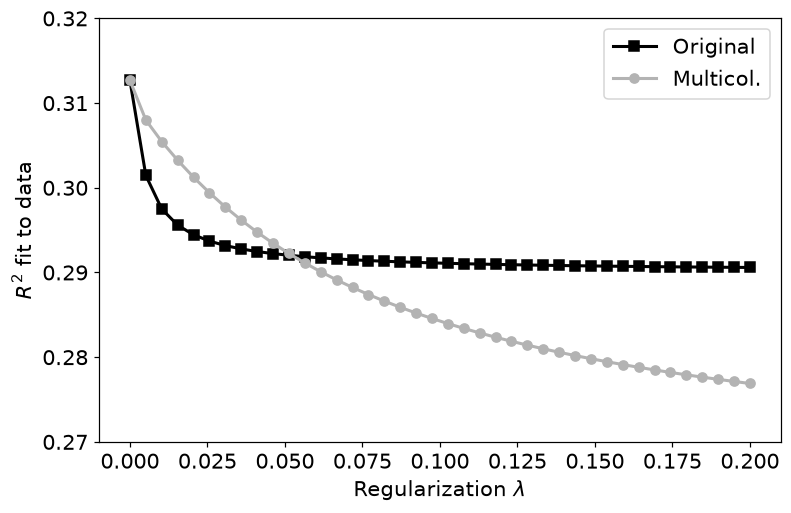

In [30]:
### Note about this code:
# Exercise 7 of chapter 12 relies on this code. Use the following toggle when you're on chapter 12 :)
I_am_reading_chapter_12 = False


# range of gamma parameters
gs = np.linspace(0,.2,40)

# initialize r2 vector
r2s  = np.zeros(gs.shape)
r2sM = np.zeros(gs.shape) # the 'M' is for multicollinearity


# loop over gammas
for i in range(len(gs)):

  # create lambda
  l = gs[i]*np.linalg.norm(desmat,'fro')**2

  if I_am_reading_chapter_12: # exercise 12.7
    l = gs[i]*np.mean(np.linalg.eig(desmat.T@desmat)[0])

  # compute left-inverse
  leftinv = np.linalg.inv(desmat.T@desmat + l*np.eye(desmat.shape[1])) @ desmat.T
  
  # compute beta and predicted data
  b = leftinv @ y
  yHat = desmat@b

  # model fit to data
  r2s[i] = np.corrcoef(y.T,yHat.T)[0,1]**2


  ### repeat for the multicollinear model (condensed for convenience)
  l       = gs[i]*np.linalg.norm(desmatM,'fro')**2
  if I_am_reading_chapter_12: # exercise 12.6
    l     = gs[i]*np.mean(np.linalg.eig(desmatM.T@desmatM)[0])
  leftinv = np.linalg.pinv(desmatM.T@desmatM + l*np.eye(desmatM.shape[1])) @ desmatM.T
  b       = leftinv @ y
  yHat    = desmatM@b
  r2sM[i] = np.corrcoef(y.T,yHat.T)[0,1]**2



# plot the results
plt.figure(figsize=(8,5))
plt.plot(gs,r2s,'ks-',linewidth=2,label='Original')
plt.plot(gs,r2sM,'o-',linewidth=2,label='Multicol.',color=[.7,.7,.7])
plt.xlabel('Regularization $\lambda$')
plt.ylabel('$R^2$ fit to data')
plt.ylim([.27,.32])
plt.legend()
plt.savefig(ASSET / 'Figure_11_10.png',dpi=140)
plt.show()

## 연습문제 5 · 다항식 차수 비교

- **목표**: 차수가 올라갈수록 학습 적합이 유연해짐을 확인합니다.
- **풀이 순서**: 고정된 연도·배가시간 표에 0~9차 다항식을 적합하고 같은 축에서 비교합니다.
- **결과 해석**: 높은 차수는 관측점에 잘 맞지만 그 사이와 밖에서 불안정할 수 있습니다. RankWarning은 큰 연도 거듭제곱과 조건수 문제를 알려 줍니다.

### 코드 11-30

- 원본: `original_py/LA4DS_ch11.py` 452–469행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<ipython-input-31-4571d8bcca0c>:7: RankWarning: Polyfit may be poorly conditioned
  beta = np.polyfit(year,doubleTime,oi)


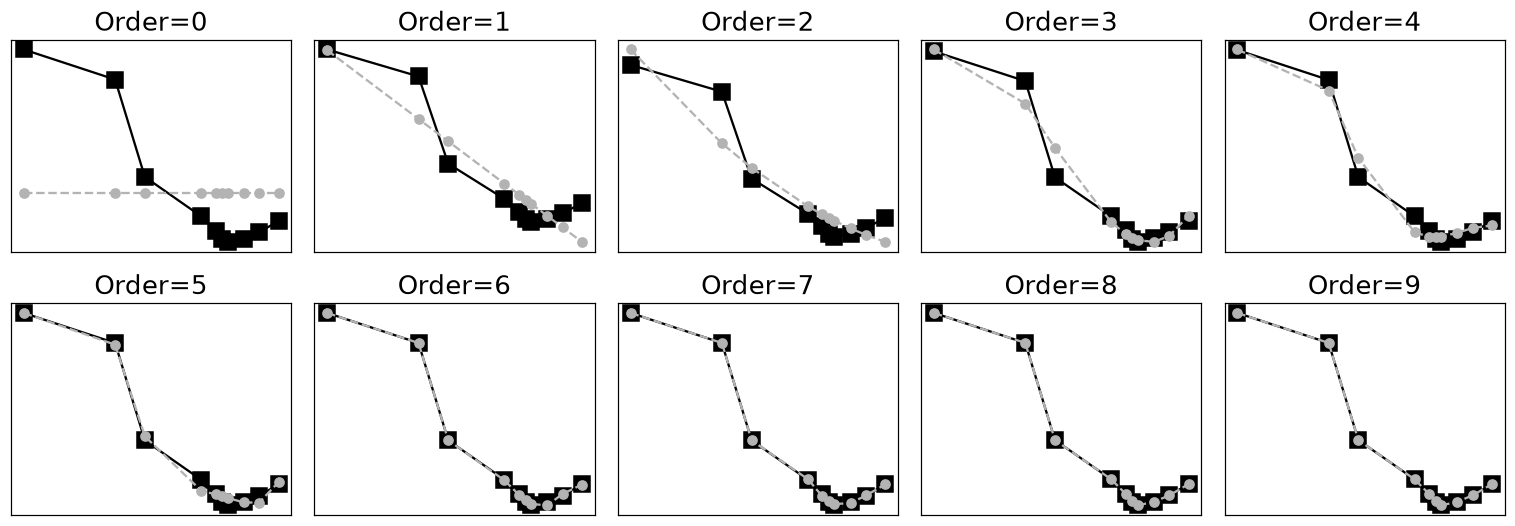

In [31]:
# plot it
_,axs = plt.subplots(2,5,figsize=(14,5))
axs = axs.flatten()


for oi in range(N):
  beta = np.polyfit(year,doubleTime,oi)
  yHat = np.polyval(beta,year)

  # plot
  axs[oi].plot(year,doubleTime,'ks-',markersize=10)
  axs[oi].plot(year,yHat,'o--',color=[.7,.7,.7])
  axs[oi].set(xticks=[], yticks=[])
  axs[oi].set_title('Order=%g' %oi)

plt.tight_layout()
plt.savefig(ASSET / 'Figure_11_11.png',dpi=140)
plt.show()

## 연습문제 6 · SSE 격자 탐색

- **목표**: 최소제곱 해를 오차 표면의 최저점으로 이해합니다.
- **풀이 순서**: 절편 100개와 기울기 100개 조합에 대해 SSE를 계산합니다. 격자 최솟값과 lstsq 해를 함께 표시합니다.
- **결과 해석**: 격자 해는 분석적 해 근처이지만 해상도 때문에 차이가 납니다. 해상도를 높이면 비용은 두 축의 격자 수 곱만큼 증가합니다.

### 코드 11-31

- 원본: `original_py/LA4DS_ch11.py` 473–479행.

In [32]:
# NOTE: data and model from the previous chapter
numcourses = [13,4,12,3,14,13,12,9,11,7,13,11,9,2,5,7,10,0,9,7]
happiness  = [70,25,54,21,80,68,84,62,57,40,60,64,45,38,51,52,58,21,75,70]

# design matrix
X = np.hstack((np.ones((20,1)),np.array(numcourses,ndmin=2).T))
beta = np.linalg.lstsq(X,happiness,rcond=None)[0]

### 코드 11-32

- 원본: `original_py/LA4DS_ch11.py` 481–529행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

Analytic result: 
   Intercept: 23.13, slope: 3.70
 
Empirical result: 
   Intercept: 22.63, slope: 3.76


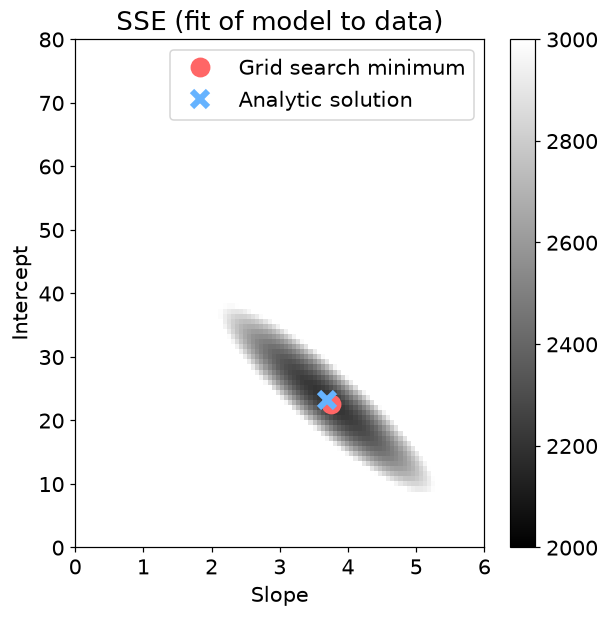

In [33]:
# the number of steps for each parameter
gridResolution = 100


# specify intercepts and slopes to test
intercepts = np.linspace(0,80,gridResolution)
slopes = np.linspace(0,6,gridResolution)

# initialize output matrix
SSEs = np.zeros((len(intercepts),len(slopes)))


# for-loops over parameters
for inti in range(len(intercepts)):
  for slopei in range(len(slopes)):

    # model-predicted data
    yHat = X @ np.array([intercepts[inti],slopes[slopei]]).T

    # sum of squared errors
    SSEs[inti,slopei] = np.sum((yHat-happiness)**2)


# find empirical minimum
i,j = np.unravel_index( np.argmin(SSEs),SSEs.shape )
empIntercept,empSlope = intercepts[i], slopes[j]


# plot the error landscape with empirical minimum
plt.figure(figsize=(6,6))
plt.imshow(SSEs,vmin=2000,vmax=3000,
           extent=[slopes[0],slopes[-1],intercepts[0],intercepts[-1]],
           origin='lower',aspect='auto',cmap='gray')
plt.plot(empSlope,empIntercept,'o',color=[1,.4,.4],markersize=12,label='Grid search minimum')
plt.plot(beta[1],beta[0],'x',color=[.4,.7,1],markeredgewidth=4,markersize=10,label='Analytic solution')
plt.colorbar()
plt.xlabel('Slope')
plt.ylabel('Intercept')
plt.title('SSE (fit of model to data)')
plt.legend()
plt.savefig(ASSET / 'Figure_11_08.png',dpi=140)
plt.show()

# print out the results
print('Analytic result: ')
print(f'   Intercept: {beta[0]:.2f}, slope: {beta[1]:.2f}')
print(' ')
print('Empirical result: ')
print(f'   Intercept: {empIntercept:.2f}, slope: {empSlope:.2f}')

## 연습문제 7 · 상관제곱 격자 탐색의 실패

- **목표**: 상관만으로 절편과 기울기를 고를 수 없음을 설명합니다.
- **풀이 순서**: 여러 직선의 예측과 y의 상관제곱을 계산하고 중심화 전후 예측선을 그립니다.
- **결과 해석**: 절편 차이는 중심화로 사라지고 양의 기울기 배율도 상관에 영향을 주지 않습니다. 기울기 0은 상관이 NaN입니다. 상관제곱과 실제 예측오차 지표를 구별해야 합니다.

### 코드 11-33

- 원본: `original_py/LA4DS_ch11.py` 533–583행.
- **보완**: 상수 예측의 상관계수 NaN을 최댓값 탐색에서 제외합니다. 상관제곱의 한계 자체는 유지합니다.

Analytic result: 
   Intercept: 23.13, slope: 3.70
 
Empirical result: 
   Intercept: 8.42, slope: 2.84


D:\Linear_Algebra\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
D:\Linear_Algebra\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


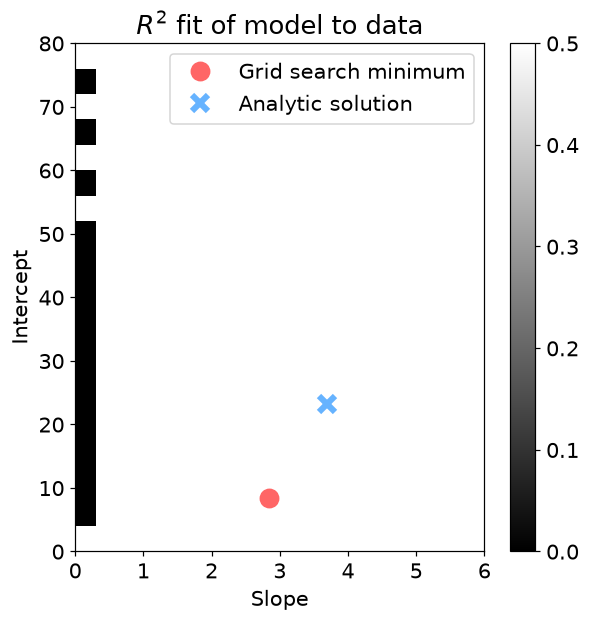

In [34]:
# the number of steps for each parameter
gridResolution = 20


# specify intercepts and slopes to test
intercepts = np.linspace(0,80,gridResolution)
slopes = np.linspace(0,6,gridResolution)

# initialize output matrix
r2 = np.zeros((len(intercepts),len(slopes)))
allYhat = np.zeros((len(intercepts),len(slopes),len(happiness)))

# for-loops over parameters
for inti in range(len(intercepts)):
  for slopei in range(len(slopes)):

    # model-predicted data
    yHat = X @ np.array([intercepts[inti],slopes[slopei]]).T

    # R2 model fit
    r2[inti,slopei] = np.corrcoef(yHat,happiness)[0,1]**2
    
    # store all predicted data values
    allYhat[inti,slopei,:] = yHat


# find empirical minimum
i,j = np.unravel_index( np.nanargmax(r2),r2.shape )
empIntercept,empSlope = intercepts[i], slopes[j]


# plot the error landscape with empirical minimum
plt.figure(figsize=(6,6))
plt.imshow(r2,vmin=0,vmax=.5,
           extent=[slopes[0],slopes[-1],intercepts[0],intercepts[-1]],
           origin='lower',aspect='auto',cmap='gray')
plt.plot(empSlope,empIntercept,'o',color=[1,.4,.4],markersize=12,label='Grid search minimum')
plt.plot(beta[1],beta[0],'x',color=[.4,.7,1],markeredgewidth=4,markersize=10,label='Analytic solution')
plt.colorbar()
plt.xlabel('Slope')
plt.ylabel('Intercept')
plt.title('$R^2$ fit of model to data')
plt.legend()
plt.show()

# print out the results
print('Analytic result: ')
print(f'   Intercept: {beta[0]:.2f}, slope: {beta[1]:.2f}')
print(' ')
print('Empirical result: ')
print(f'   Intercept: {empIntercept:.2f}, slope: {empSlope:.2f}')

### 코드 11-34

- 원본: `original_py/LA4DS_ch11.py` 585–609행.

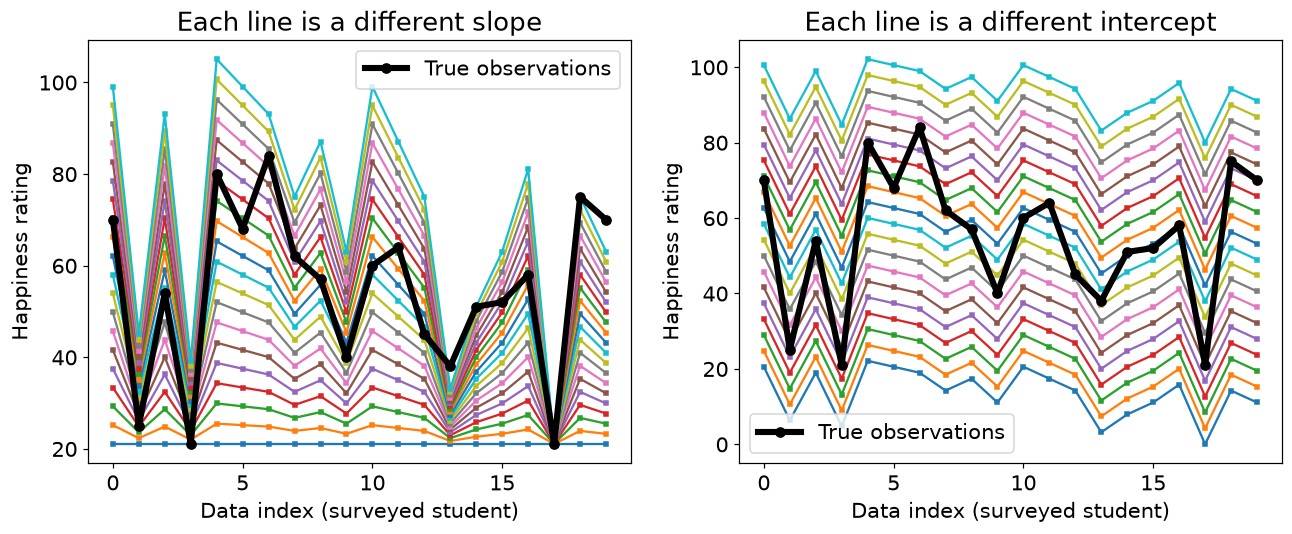

In [35]:
# Why doesn't this approach work? 
# Let's start by plotting predicted data for different parameters.

_,axs = plt.subplots(1,2,figsize=(14,5))

axs[0].plot(allYhat[5,:,:].T,'s-',markersize=3)
axs[0].plot(happiness,'ko-',linewidth=4,label='True observations')
axs[0].set_xlabel('Data index (surveyed student)')
axs[0].set_ylabel('Happiness rating')
axs[0].set_title('Each line is a different slope')
axs[0].legend()

axs[1].plot(allYhat[:,5,:].T,'s-',markersize=3)
axs[1].plot(happiness,'ko-',linewidth=4,label='True observations')
axs[1].set_xlabel('Data index (surveyed student)')
axs[1].set_ylabel('Happiness rating')
axs[1].set_title('Each line is a different intercept')
axs[1].legend()

plt.show()

# The plots show that the predicted values are quite similar for different parameter pairs.
# Recall that data are mean-centered in the correlation formula. In fact, we can re-plot these
# predicted data after mean-centering, i.e., the way a correlation would see the data. 
# Move on to the next cell...

### 코드 11-35

- 원본: `original_py/LA4DS_ch11.py` 611–636행.

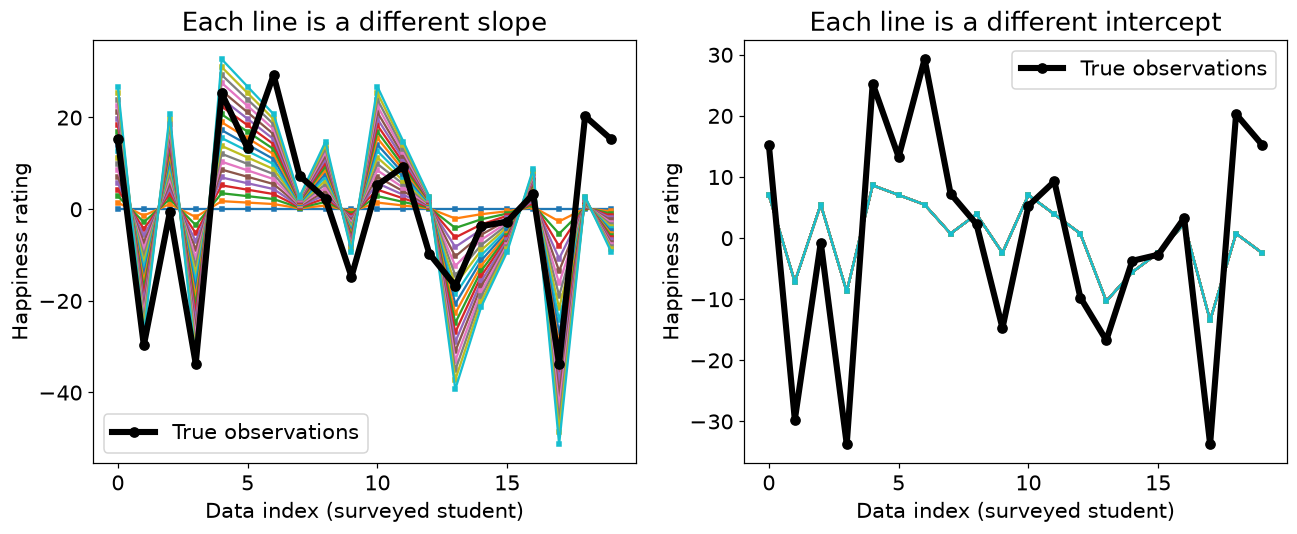

In [36]:
# The plots here are the same as above, but all data have been mean-centered.

_,axs = plt.subplots(1,2,figsize=(14,5))

axs[0].plot(allYhat[5,:,:].T - np.mean(allYhat[5,:,:].T,axis=0),'s-',markersize=3)
axs[0].plot(happiness-np.mean(happiness),'ko-',linewidth=4,label='True observations')
axs[0].set_xlabel('Data index (surveyed student)')
axs[0].set_ylabel('Happiness rating')
axs[0].set_title('Each line is a different slope')
axs[0].legend()

axs[1].plot(allYhat[:,5,:].T - np.mean(allYhat[:,5,:].T,axis=0),'s-',markersize=3)
axs[1].plot(happiness-np.mean(happiness),'ko-',linewidth=4,label='True observations')
axs[1].set_xlabel('Data index (surveyed student)')
axs[1].set_ylabel('Happiness rating')
axs[1].set_title('Each line is a different intercept')
axs[1].legend()

plt.show()

# All of the intercept terms have collapsed into a single line -- not surprising considering that
# the intercept term of a linear model _is_ simply a mean offset.
# 
# The conclusion of this investigation is that R^2 is not a useful model fit metric in this example.
# Of course, that doesn't mean it never a useful model; instead, it means that you need to think
# carefully about the metrics you use to evaluate model fit to data.

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [37]:
_y=np.array([1.,2.,3.,4.]); _pred=_y+100
_corr2=np.corrcoef(_y,_pred)[0,1]**2
_r2=1-np.sum((_y-_pred)**2)/np.sum((_y-_y.mean())**2)
print('100만큼 틀린 예측의 상관제곱:',_corr2)
print('같은 예측의 1-SSE/SST:',_r2)
assert np.isclose(_corr2,1) and _r2<0
_D=np.array([[1.,1.],[2.,2.],[3.,3.]])
_G=_D.T@_D+.1*np.eye(2)
print('정규화 전/후 랭크:',np.linalg.matrix_rank(_D.T@_D),np.linalg.matrix_rank(_G))
assert np.linalg.matrix_rank(_G)==2


100만큼 틀린 예측의 상관제곱: 1.0
같은 예측의 1-SSE/SST: -7999.0
정규화 전/후 랭크: 1 2
